In [1]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
# from skmultilearn.model_selection import iterative_train_test_split
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

In [2]:
file_path1 = "data/stratified_test_data_pinfo.json"  # Update with your actual file path
with open(file_path1, "r") as f:
    data1 = json.load(f)
file_path2 = "data/stratified_train_data_pinfo.json"  # Update with your actual file path
with open(file_path2, "r") as f:
    data2 = json.load(f)

In [3]:
len(data1 + data2)

1135

In [4]:
len(data1)

248

In [5]:
data1[:2]

[{'text': "From Patient: Dr.Person1 I need my prescription sent to the pharmacy for my flecainide acetate 100 mg tablets twice a day the pharmacist has try requesting it no success and I don't have any pills. Person2",
  'labels': ['CareCoordinationPatient_None',
   'PartnershipPatient_Clinical care',
   'PartnershipPatient_activeParticipation/involvement',
   'SDOH_HealthCareAccessAndQuality',
   'SDOH_NeighborhoodAndBuiltEnvironment']},
 {'text': 'From Patient: Hi Dr. Person1,I left two messages last week on MM/DD/YYYY and MM/DD/YYYY. Asking about stopping the eliquis for the second time on this month since I had the first procedure of diagnostic lumbar facet block.RF ABLATION.AND DR.Person 2 wants to know for my second dose is scheduled for MM/DD/YYYY he wants to know if I cud have it done that date or cud schedule it a bit further date,since I have to stop the eliquis three days prior to the procedure. Thank you, Person2',
  'labels': ['CareCoordinationPatient_None',
   'Partnershi

In [6]:
data = data1 + data2

In [7]:
len(data)

1135

In [21]:
from collections import defaultdict
# get the dist
def get_dist(data):
    code_dist = defaultdict(int)
    subcode_dist = defaultdict(int)
    combo_dist = defaultdict(int)
    for item in data:
        for l in item['labels']:
            code, subcode = l.split("_")
            if subcode == "Clinical care":
                subcode = "Clinical Care"
            code_dist[code] += 1
            subcode_dist[subcode] += 1
            combo_dist[l] += 1
    return code_dist, subcode_dist, combo_dist
# get the dist
def get_dist_message_wise(data):
    # remove dups in message
    code_dist = defaultdict(int)
    subcode_dist = defaultdict(int)
    combo_dist = defaultdict(int)
    for item in data:
        code_set = set()
        subcode_set = set()
        combo_set = set()
        for l in item['labels']:
            code, subcode = l.split("_")
            if subcode == "Clinical care":
                subcode = "Clinical Care"
            if code == "PartnershipPatient" and subcode == "None":
                continue
                #PartnershipPatient_None
            code_set.add(code)
            if subcode != "None":
                subcode_set.add(subcode)
            combo_set.add(l)
        for code in code_set:
            code_dist[code] += 1
        for subcode in subcode_set:
            subcode_dist[subcode] += 1
        for combo in combo_set:
            combo_dist[combo] += 1
    return code_dist, subcode_dist, combo_dist
cd, sd, cmd = get_dist_message_wise(data)

In [22]:
cd

defaultdict(int,
            {'PartnershipPatient': 671,
             'CareCoordinationPatient': 182,
             'SDOH': 536,
             'SharedDecisionPatient': 163,
             'SharedDecisionProvider': 108,
             'PartnershipProvider': 378,
             'SocioEmotionalBehaviour': 242,
             'CareCoordinationProvider': 162})

In [23]:
sd

defaultdict(int,
            {'activeParticipation/involvement': 453,
             'Clinical Care': 731,
             'NeighborhoodAndBuiltEnvironment': 91,
             'HealthCareAccessAndQuality': 303,
             'ExploreOptions': 61,
             'signoff': 406,
             'salutation': 463,
             'SeekingApproval': 107,
             'alignment': 101,
             'expressOpinions': 177,
             'MakeDecision': 73,
             'inviteCollabration': 126,
             'Appreciation/Gratitude': 153,
             'connection': 121,
             'build trust': 37,
             'checkingUnderstanding/clarification': 61,
             'maintainCommunication': 98,
             'ShareOptions': 36,
             'SocialAndCommunityContext': 129,
             'Approval/Reinforcement': 13,
             'EconomicStability': 160,
             'ApprovalofDecision/Reinforcement': 10,
             'requestsForOpinion': 39,
             'statePreferences': 74,
             'EducationA

In [24]:
cmd

defaultdict(int,
            {'PartnershipPatient_activeParticipation/involvement': 453,
             'PartnershipPatient_Clinical care': 487,
             'CareCoordinationPatient_None': 182,
             'SDOH_HealthCareAccessAndQuality': 303,
             'SDOH_NeighborhoodAndBuiltEnvironment': 91,
             'SharedDecisionPatient_ExploreOptions': 61,
             'PartnershipPatient_salutation': 260,
             'PartnershipPatient_signoff': 256,
             'SharedDecisionPatient_SeekingApproval': 107,
             'PartnershipPatient_alignment': 49,
             'PartnershipPatient_expressOpinions': 177,
             'PartnershipProvider_Clinical Care': 257,
             'SharedDecisionProvider_MakeDecision': 73,
             'PartnershipProvider_signoff': 151,
             'PartnershipProvider_salutation': 203,
             'SocioEmotionalBehaviour_None': 242,
             'PartnershipProvider_inviteCollabration': 126,
             'PartnershipPatient_Appreciation/Gratitude

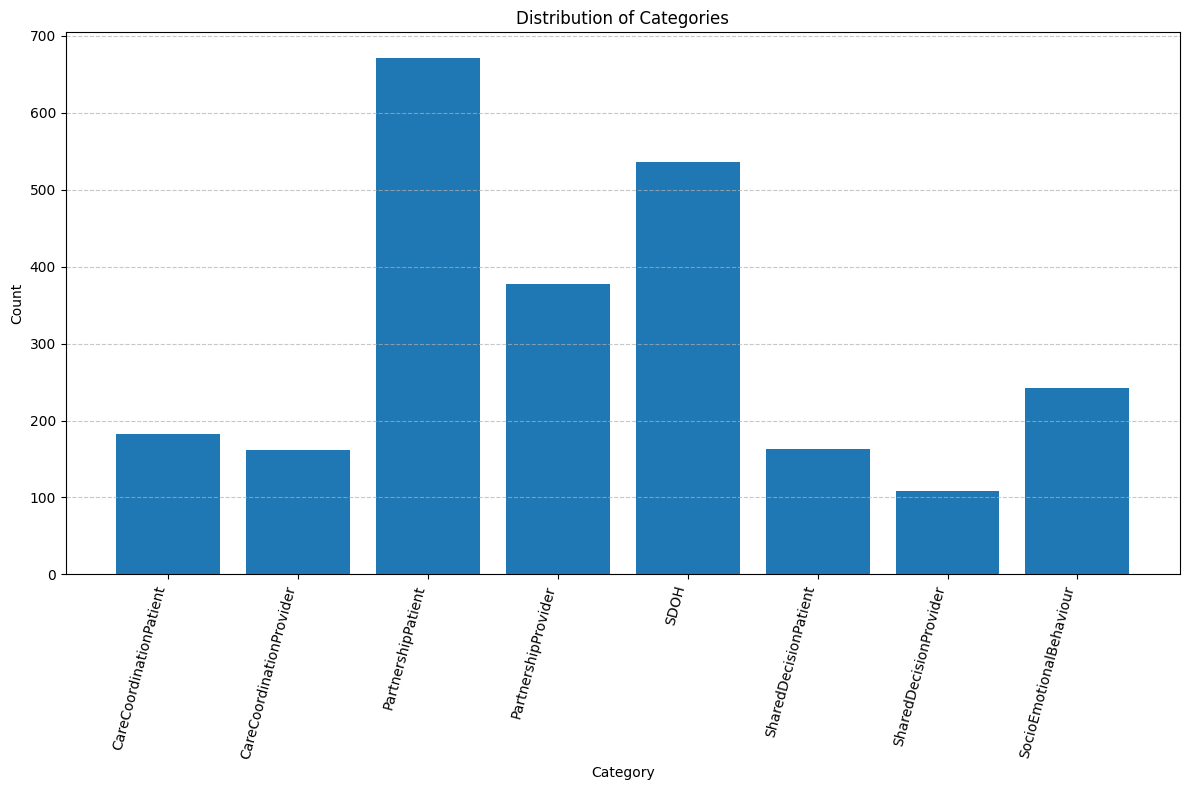

In [28]:
import matplotlib.pyplot as plt
from collections import defaultdict
def get_plot(data, name):
    # sort by key
    sorted_items = sorted(data.items(), key=lambda x: x[0])
    keys, values = zip(*sorted_items)
    
    # plot
    plt.figure(figsize=(12, 8))
    plt.bar(keys, values)
    plt.xticks(rotation=75, ha='right')
    plt.title('Distribution of Categories')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # add numbers on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 5,           # slightly above bar
            f'{int(height)}',     # integer label
            ha='center', va='bottom', fontsize=8, rotation=90
        )
    plt.show()
    # save as PDF
    plt.savefig(f"{name}_distribution.pdf", format='pdf')
    plt.close()
get_plot(cd, "code")

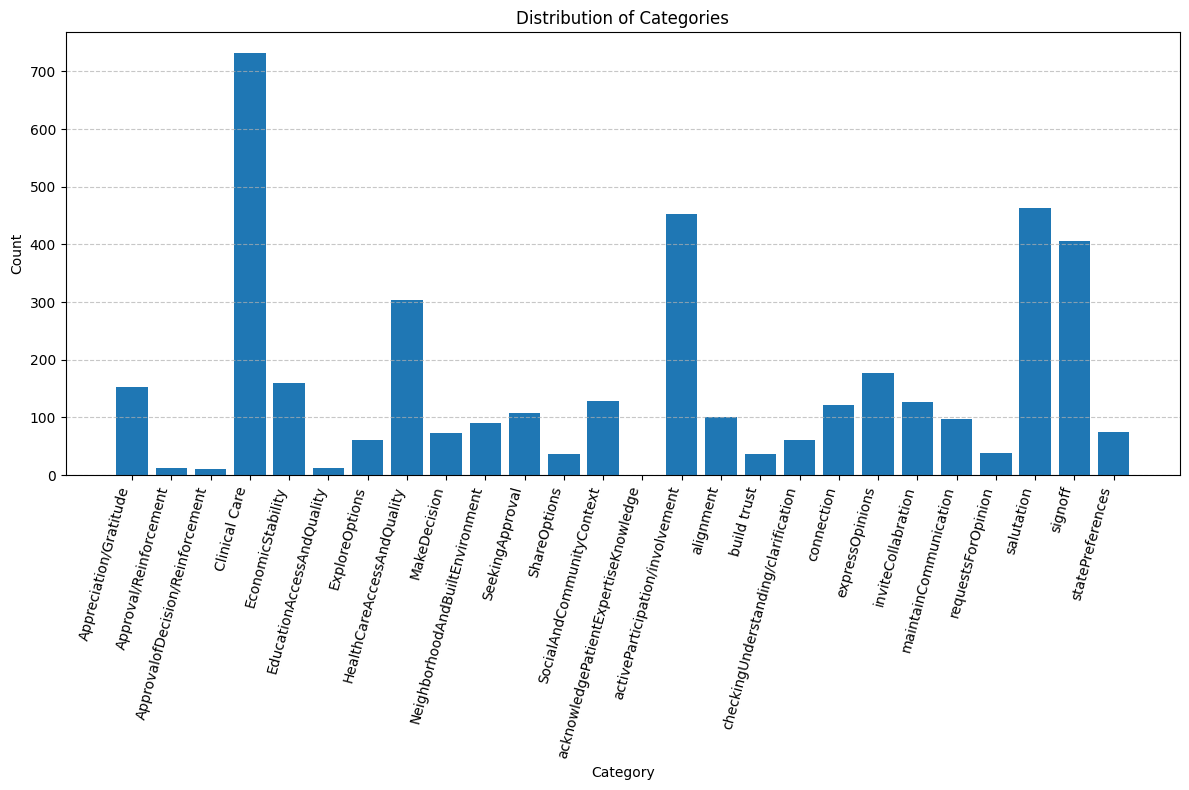

In [29]:
get_plot(sd, "subcode")

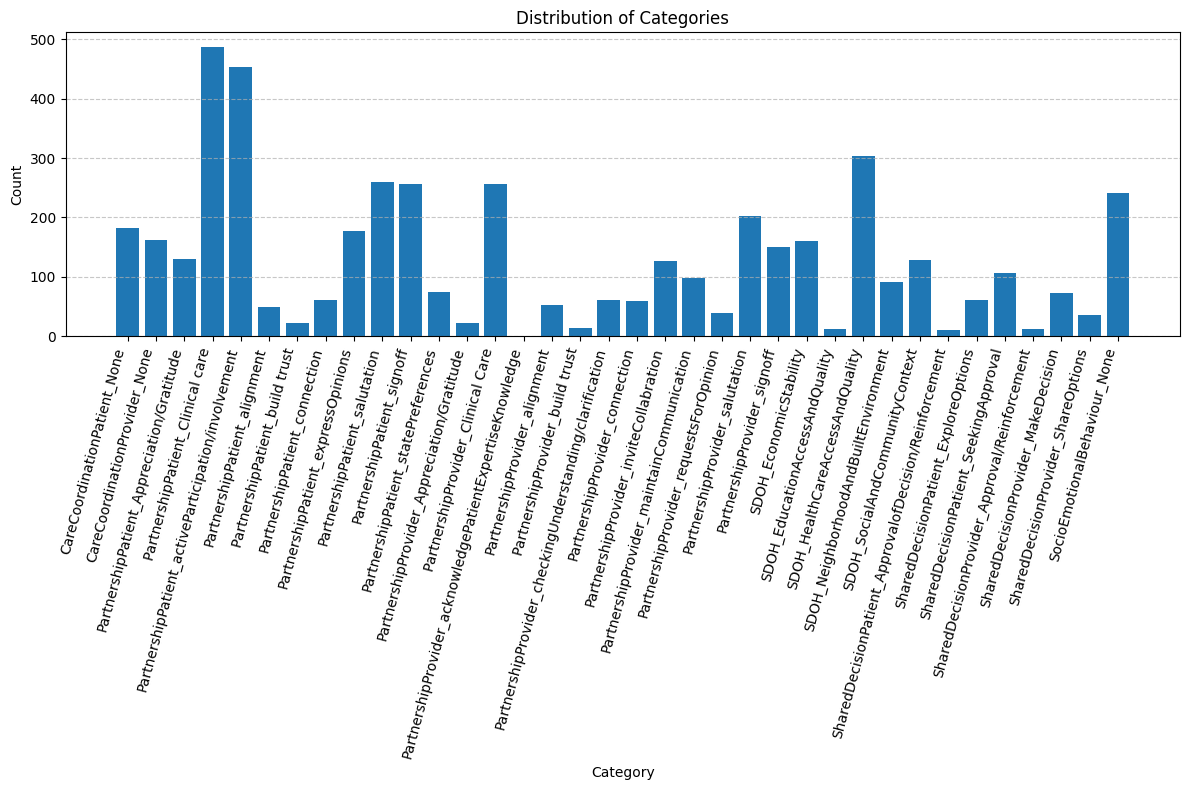

In [30]:
get_plot(cmd, "combo")

In [10]:
count = 0
for k,v in cd.items():
    count += v
count
    

2442

In [11]:
len(data1)

248

In [12]:
len(data2)

887